#Credit Card Fraud Detection using Machine Learning

Credit card fraud detection is an important application of machine learning in the financial sector. Fraudulent transactions can cause significant financial losses for banks and customers, so detecting them quickly is essential.

In this project, a machine learning model is built to classify credit card transactions as fraudulent or legitimate using transaction data. Algorithms such as Logistic Regression, Decision Tree, and Random Forest are used to train and evaluate the model to identify suspicious transactions accurately.

#Import Required Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Load the Dataset

In [18]:
train_data = pd.read_csv('fraudTrain.csv')
test_data = pd.read_csv('fraudTest.csv')

train_data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


#Dataset Information

In [19]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38896 entries, 0 to 38895
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             38896 non-null  int64  
 1   trans_date_trans_time  38896 non-null  object 
 2   cc_num                 38896 non-null  int64  
 3   merchant               38896 non-null  object 
 4   category               38896 non-null  object 
 5   amt                    38896 non-null  float64
 6   first                  38896 non-null  object 
 7   last                   38896 non-null  object 
 8   gender                 38895 non-null  object 
 9   street                 38895 non-null  object 
 10  city                   38895 non-null  object 
 11  state                  38895 non-null  object 
 12  zip                    38895 non-null  float64
 13  lat                    38895 non-null  float64
 14  long                   38895 non-null  float64
 15  ci

In [20]:
print("Training Dataset Shape:", train_data.shape)
print("Testing Dataset Shape:", test_data.shape)

train_data.info()
test_data.info()

Training Dataset Shape: (112753, 23)
Testing Dataset Shape: (38896, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112753 entries, 0 to 112752
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             112753 non-null  int64  
 1   trans_date_trans_time  112753 non-null  object 
 2   cc_num                 112753 non-null  int64  
 3   merchant               112753 non-null  object 
 4   category               112753 non-null  object 
 5   amt                    112753 non-null  float64
 6   first                  112753 non-null  object 
 7   last                   112753 non-null  object 
 8   gender                 112753 non-null  object 
 9   street                 112753 non-null  object 
 10  city                   112753 non-null  object 
 11  state                  112753 non-null  object 
 12  zip                    112753 non-null  int64  
 13  lat              

In [21]:
train_data.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,112753.000000,1.127530e+05,112753.000000,112753.000000,112753.000000,112753.000000,1.127530e+05,1.127520e+05,112752.000000,112752.000000,112752.000000
mean,56376.000000,4.166699e+17,71.718918,48746.317304,38.539319,-90.194076,8.911778e+04,1.328232e+09,38.540894,-90.194801,0.009348
std,32549.131788,1.307557e+18,148.764850,26909.379927,5.072703,13.775194,3.010021e+05,1.634156e+06,5.105767,13.786551,0.096232
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.670132,0.000000
25%,28188.000000,1.800365e+14,9.680000,26041.000000,34.668900,-96.798000,7.430000e+02,1.326802e+09,34.757207,-96.888217,0.000000
50%,56376.000000,3.519607e+15,48.040000,48174.000000,39.371600,-87.461600,2.456000e+03,1.328274e+09,39.365649,-87.409035,0.000000
75%,84564.000000,4.635331e+15,83.780000,72011.000000,41.846700,-80.128400,2.047800e+04,1.329640e+09,41.940148,-80.185479,0.000000
max,112752.000000,4.992346e+18,12788.070000,99783.000000,65.689900,-67.950300,2.906700e+06,1.330898e+09,66.659242,-66.967742,1.000000


#Data Preprocessing
**Check Fraud vs Legitimate Transactions**

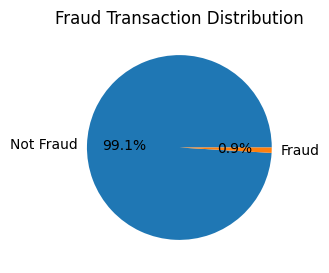

In [23]:
fraud_counts = train_data['is_fraud'].value_counts()

plt.figure(figsize=(3,3))  # smaller graph
plt.pie(fraud_counts, labels=['Not Fraud','Fraud'], autopct='%1.1f%%')
plt.title("Fraud Transaction Distribution")
plt.show()

**Feature Selection**

In [24]:
X = train_data.select_dtypes(include=['int64','float64']).drop('is_fraud', axis=1)
y = train_data['is_fraud']

In [30]:
X = X.dropna()
y = y[X.index]

In [31]:
print("Features used for training:")
print(X.columns)

Features used for training:
Index(['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop',
       'unix_time', 'merch_lat', 'merch_long'],
      dtype='object')


#Train-Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (90201, 10)
Testing data: (22551, 10)


#Model Training – Logistic Regression

In [37]:
from sklearn.linear_model import LogisticRegression

In [18]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [41]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

**Model Prediction**

In [42]:
y_pred = log_model.predict(X_test)

#Model Accuracy

In [43]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 99.11%


In [46]:
rf_model = RandomForestClassifier(class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     22351
         1.0       0.88      0.64      0.74       200

    accuracy                           1.00     22551
   macro avg       0.94      0.82      0.87     22551
weighted avg       1.00      1.00      1.00     22551



#Model Evaluation
**Confusion Matrix**

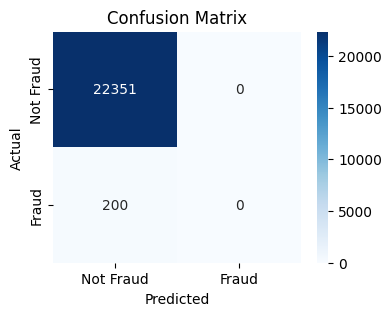

In [47]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Decision Tree**

In [49]:
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [50]:
y_pred_dt = dt_model.predict(X_test)

In [51]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy: {:.2f}%".format(accuracy_dt * 100))

Decision Tree Accuracy: 99.26%


Decision Tree Confusion Matrix

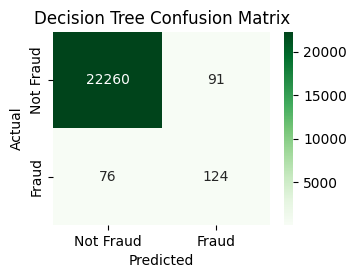

In [52]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(3.5,2.5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Random Forest**

In [53]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [54]:
y_pred_rf = rf_model.predict(X_test)

In [55]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy: {:.2f}%".format(accuracy_rf * 100))

Random Forest Accuracy: 99.58%


In [56]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     22351
         1.0       0.84      0.65      0.73       200

    accuracy                           1.00     22551
   macro avg       0.92      0.82      0.87     22551
weighted avg       1.00      1.00      1.00     22551



**Random Forest Confusion Matrix**

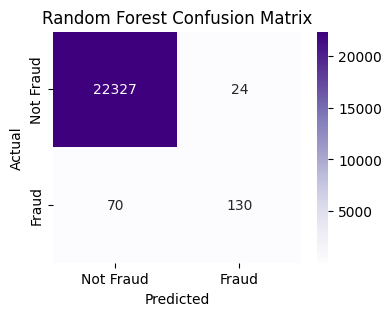

In [57]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(4,3))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Fraud','Fraud'],
            yticklabels=['Not Fraud','Fraud'])

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Test Using a Real Transaction

In [62]:
sample1 = X_test.iloc[[0]]

pred1 = rf_model.predict(sample1)

print("Prediction:", pred1)
print("Actual:", y_test.iloc[0])

Prediction: [0.]
Actual: 0.0


In [63]:
samples = X_test.iloc[[0, 10, 25]]

predictions = rf_model.predict(samples)

print("Predictions:", predictions)

Predictions: [0. 0. 0.]


#Conclusion

This project built a machine learning model to detect fraudulent credit card transactions. Logistic Regression, Decision Tree, and Random Forest algorithms were trained and evaluated.

The models successfully classified transactions as fraud or legitimate, and Random Forest achieved the best performance. This demonstrates how machine learning can help improve fraud detection in financial systems.